Load and inspect data

In [20]:
import os
print(os.getcwd())

c:\Users\hp\OneDrive\Desktop\kifiya\Week 01\github\solar-challenge-week1\notebooks


Load teh data


In [21]:
import pandas as pd

df = pd.read_csv("../data/sierraleone-bumbuna.csv")  # or togo-dapaong.csv
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB          525600 non-nul

Summary Status and Missing Values 

In [22]:
df.describe()

missing = df.isna().sum()
missing[missing > 0]
null_thresh = len(df) * 0.05

Outlier Detection and Cleaning Using Z-Score Method 

In [23]:
from scipy.stats import zscore

cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
df_z = df[cols_to_check].apply(zscore)

outliers = (df_z.abs() > 3)
outlier_counts = outliers.sum()
print(outlier_counts)

GHI       2477
DNI       7586
DHI       2986
ModA      1604
ModB      2041
WS        3967
WSgust    3665
dtype: int64


Cleaning and Add Cleaning Flag

In [24]:
for col in cols_to_check: 
    df[col] = df[col].fillna(df[col].median())

In [25]:
df['Cleaning_flag'] = outliers.any(axis=1).astype(int)

Save Cleaned Data

In [26]:
df.to_csv("../data/sierraleone_clean.csv", index=False)

Time Series Analysis

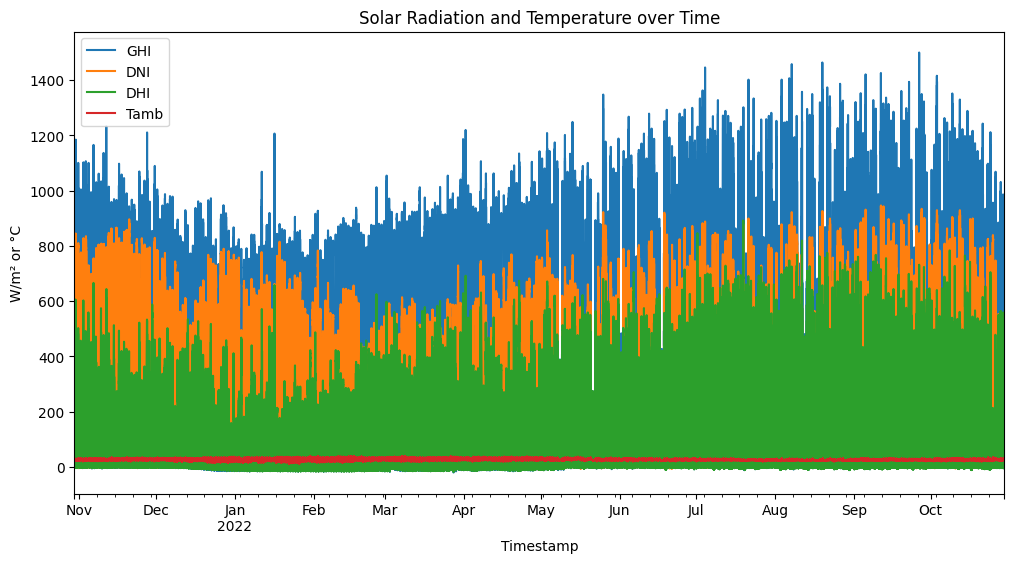

In [27]:
import matplotlib.pyplot as plt

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

df[['GHI', 'DNI', 'DHI', 'Tamb']].plot(figsize=(12, 6))
plt.title('Solar Radiation and Temperature over Time')
plt.ylabel('W/m² or °C')
plt.show()

Cleaning Impact 

In [28]:
df.groupby('cleaning_flag')[['ModA', 'ModB']].mean().plot(kind='bar')
plt.title('ModA & ModB Averages Before vs After Cleaning')
plt.show()

KeyError: 'cleaning_flag'

Correlation Analysis Using Seaborn and Scatter Plots 

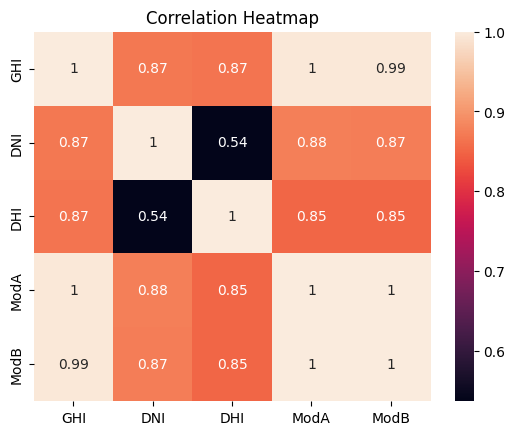

In [29]:
import seaborn as sns

sns.heatmap(df[['GHI', 'DNI', 'DHI', 'ModA', 'ModB']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

Scatte rplot Wind Speed vs GHI

Text(0.5, 1.0, 'Wind Speed vs GHI')

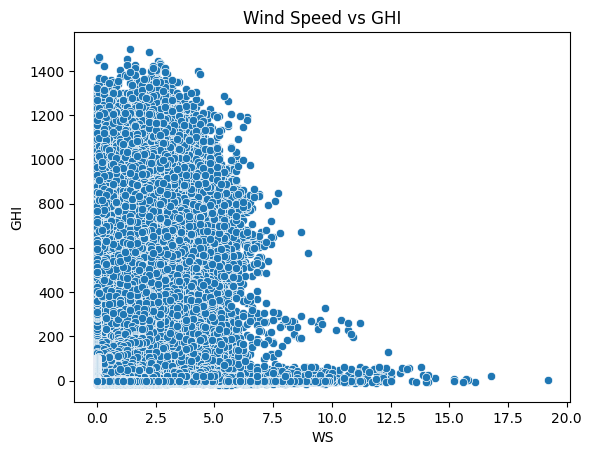

In [30]:
sns.scatterplot(data=df, x='WS', y='GHI')
plt.title('Wind Speed vs GHI')

Wind and Distribution Analysis Using HistoGram

Text(0.5, 1.0, 'Distribution of Wind Speed')

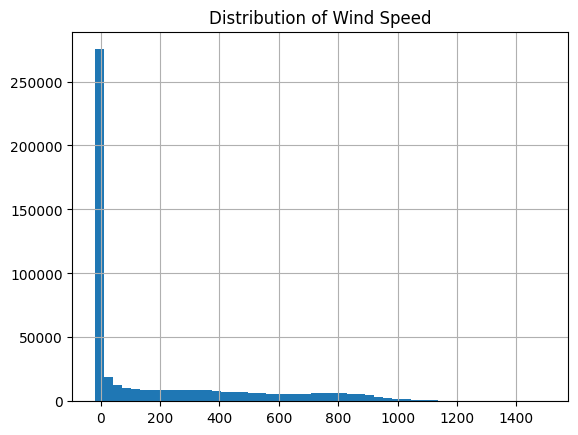

In [31]:
df['GHI'].hist(bins=50)
plt.title('Distribution of GHI')

df['WS'].hist(bins=50)
plt.title('Distribution of Wind Speed')

Tempreture Analysis 

Text(0.5, 1.0, 'RH vs GHI')

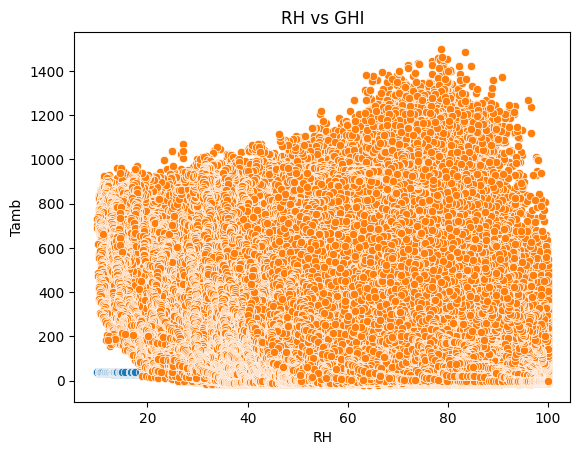

In [32]:
sns.scatterplot(data=df, x='RH', y='Tamb')
plt.title('RH vs Temperature')

sns.scatterplot(data=df, x='RH', y='GHI')
plt.title('RH vs GHI')

Bubble Chart 

Text(0.5, 1.0, 'GHI vs Tamb (Bubble size = RH)')

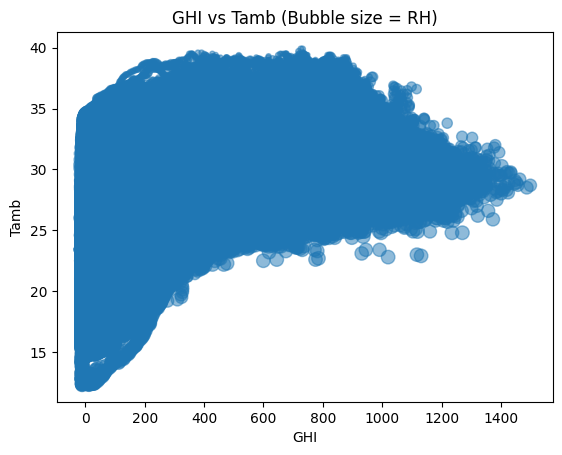

In [33]:
plt.scatter(df['GHI'], df['Tamb'], s=df['RH'], alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Tamb')
plt.title('GHI vs Tamb (Bubble size = RH)')